In [1]:
# Run this cell before writing your solution
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from seqeval.metrics import f1_score
import urllib.request

# Download dataset
url = "https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/conll_ner_dataset.csv"
urllib.request.urlretrieve(url, "conll_ner_dataset.csv")

df = pd.read_csv("conll_ner_dataset.csv", encoding="utf-8")

Using Apple Silicon GPU (MPS)
Device: mps
Number of sentences: 17291
First sentence:
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']

Training sentences: 13832
Validation sentences: 3459

Vocabulary size: 10929
PAD index: 0
UNK index: 1

Tag vocabulary:
{'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6, 'B-MISC': 7, 'I-MISC': 8}

Train batches: 217
Validation batches: 55

BiLSTM Model:
BiLSTMNER(
  (embedding): Embedding(10929, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=9, bias=True)
)

TRAINING BiLSTM
Epoch [01/15] Loss: 0.6476 | Validation F1: 0.4131
Epoch [02/15] Loss: 0.3153 | Validation F1: 0.6493
Epoch [03/15] Loss: 0.2014 | Validation F1: 0.7345
Epoch [04/15] Loss: 0.1451 | Validation F1: 0.7718
Epoch [05/15] 

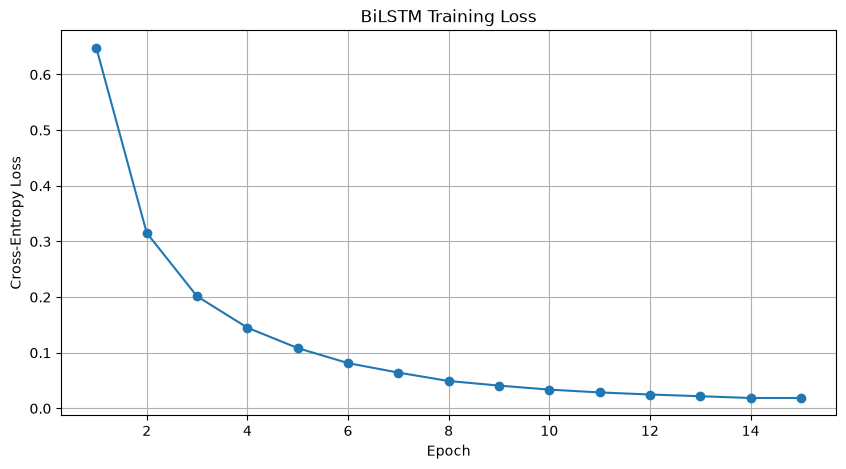

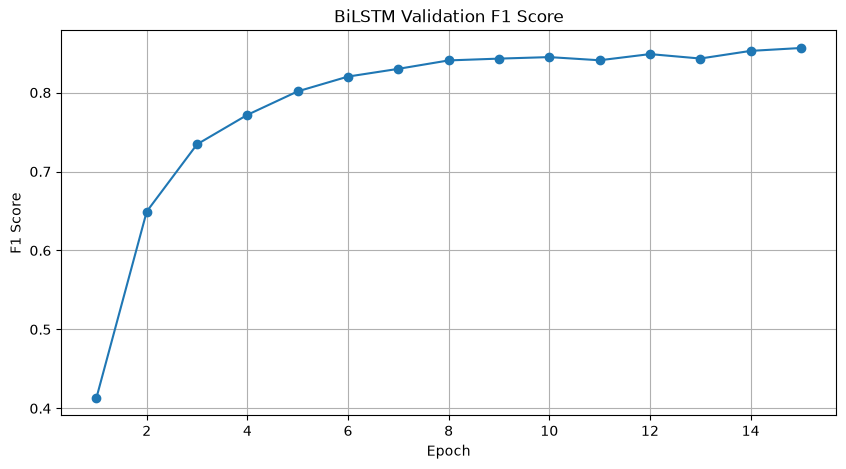


REQUIRED OUTPUTS
word2idx type: <class 'dict'>
word2idx size: 10929

tag2idx:
{'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6, 'B-MISC': 7, 'I-MISC': 8}

model type: <class '__main__.BiLSTMNER'>

Final Validation F1: 0.8565


In [2]:
# ============================================================
# Named Entity Recognition on News Articles using BiLSTM
# MacBook Air M4 - Apple Silicon MPS Version
# ============================================================

# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("MPS not available - using CPU")

print("Device:", device)


# ------------------------------------------------------------
# 2. Load and preprocess dataset
# ------------------------------------------------------------

# Forward-fill Sentence #
df["Sentence #"] = df["Sentence #"].ffill()

# Remove rows with missing Word or Tag
df = df.dropna(
    subset=["Sentence #", "Word", "Tag"]
).reset_index(drop=True)

# Group words and tags by sentence
sentences = []
tags = []

for sentence_id, group in df.groupby("Sentence #"):

    words = group["Word"].astype(str).tolist()
    sentence_tags = group["Tag"].astype(str).tolist()

    sentences.append(words)
    tags.append(sentence_tags)

print("Number of sentences:", len(sentences))
print("First sentence:")
print(sentences[0])
print(tags[0])


# ------------------------------------------------------------
# 3. Train / Validation Split
# ------------------------------------------------------------

train_sentences, val_sentences, train_tags, val_tags = train_test_split(
    sentences,
    tags,
    test_size=0.2,
    random_state=42
)

print("\nTraining sentences:", len(train_sentences))
print("Validation sentences:", len(val_sentences))


# ------------------------------------------------------------
# 4. Build word vocabulary
# ------------------------------------------------------------

from collections import Counter

# Count words only in training data
word_counter = Counter()

for sentence in train_sentences:
    for word in sentence:
        word_counter[word.lower()] += 1


# Required special tokens
word2idx = {
    "<PAD>": 0,
    "<UNK>": 1
}


# Add words occurring at least 2 times
for word, count in word_counter.items():

    if count >= 2:
        word2idx[word] = len(word2idx)


print("\nVocabulary size:", len(word2idx))
print("PAD index:", word2idx["<PAD>"])
print("UNK index:", word2idx["<UNK>"])


# ------------------------------------------------------------
# 5. Build tag vocabulary
# ------------------------------------------------------------

# Required 9 BIO tags
tag_list = [
    "O",
    "B-PER",
    "I-PER",
    "B-ORG",
    "I-ORG",
    "B-LOC",
    "I-LOC",
    "B-MISC",
    "I-MISC"
]

tag2idx = {
    tag: idx
    for idx, tag in enumerate(tag_list)
}

idx2tag = {
    idx: tag
    for tag, idx in tag2idx.items()
}

print("\nTag vocabulary:")
print(tag2idx)


# ------------------------------------------------------------
# 6. Encode sentences and tags
# ------------------------------------------------------------

def encode_sentence(sentence):
    return [
        word2idx.get(
            word.lower(),
            word2idx["<UNK>"]
        )
        for word in sentence
    ]


def encode_tags(sentence_tags):
    return [
        tag2idx[tag]
        for tag in sentence_tags
    ]


train_encoded = [
    encode_sentence(sentence)
    for sentence in train_sentences
]

val_encoded = [
    encode_sentence(sentence)
    for sentence in val_sentences
]

train_tags_encoded = [
    encode_tags(sentence_tags)
    for sentence_tags in train_tags
]

val_tags_encoded = [
    encode_tags(sentence_tags)
    for sentence_tags in val_tags
]


# ------------------------------------------------------------
# 7. PyTorch Dataset
# ------------------------------------------------------------

class NERDataset(Dataset):

    def __init__(self, sentences, tags):

        self.sentences = sentences
        self.tags = tags

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, index):

        words = torch.tensor(
            self.sentences[index],
            dtype=torch.long
        )

        labels = torch.tensor(
            self.tags[index],
            dtype=torch.long
        )

        return words, labels


train_dataset = NERDataset(
    train_encoded,
    train_tags_encoded
)

val_dataset = NERDataset(
    val_encoded,
    val_tags_encoded
)


# ------------------------------------------------------------
# 8. Collate function
# ------------------------------------------------------------

def collate_fn(batch):

    words, labels = zip(*batch)

    # Word padding = 0
    padded_words = pad_sequence(
        words,
        batch_first=True,
        padding_value=0
    )

    # Tag padding = -1
    padded_labels = pad_sequence(
        labels,
        batch_first=True,
        padding_value=-1
    )

    return padded_words, padded_labels


# ------------------------------------------------------------
# 9. DataLoaders
# ------------------------------------------------------------

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

print("\nTrain batches:", len(train_loader))
print("Validation batches:", len(val_loader))


# ============================================================
# BiLSTM MODEL
# ============================================================

# ------------------------------------------------------------
# 10. Define BiLSTM model
# ------------------------------------------------------------

class BiLSTMNER(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        num_tags=9,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_dim * 2,
            num_tags
        )

    def forward(self, x):

        # Embedding
        embedded = self.embedding(x)

        # BiLSTM
        lstm_output, _ = self.lstm(embedded)

        # Dropout
        lstm_output = self.dropout(
            lstm_output
        )

        # Final classification layer
        logits = self.fc(lstm_output)

        return logits


# IMPORTANT:
# The required final model variable is exactly "model"

model = BiLSTMNER(
    vocab_size=len(word2idx),
    embedding_dim=128,
    hidden_dim=128,
    num_tags=9,
    dropout=0.3
).to(device)

print("\nBiLSTM Model:")
print(model)


# ------------------------------------------------------------
# 11. Loss and optimizer
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    ignore_index=-1
)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)


# ============================================================
# TRAINING
# ============================================================

# ------------------------------------------------------------
# 12. Training loop
# ------------------------------------------------------------

epochs = 15

train_losses = []
val_f1_scores = []

print("\n" + "=" * 60)
print("TRAINING BiLSTM")
print("=" * 60)

for epoch in range(epochs):

    model.train()

    total_loss = 0.0

    for words, labels in train_loader:

        # Move data to M4 GPU
        words = words.to(device)
        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(words)

        # Reshape for CrossEntropyLoss
        loss = criterion(
            logits.reshape(-1, 9),
            labels.reshape(-1)
        )

        # Backpropagation
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        # Update weights
        optimizer.step()

        total_loss += (
            loss.item() * words.size(0)
        )

    avg_loss = (
        total_loss /
        len(train_loader.dataset)
    )

    train_losses.append(avg_loss)


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()

    true_sequences = []
    pred_sequences = []

    with torch.no_grad():

        for words, labels in val_loader:

            words = words.to(device)

            logits = model(words)

            predictions = torch.argmax(
                logits,
                dim=-1
            ).cpu().numpy()

            labels_np = labels.numpy()

            for pred, true in zip(
                predictions,
                labels_np
            ):

                # Remove padding positions
                valid_length = np.sum(
                    true != -1
                )

                pred = pred[:valid_length]
                true = true[:valid_length]

                pred_tags = [
                    idx2tag[int(idx)]
                    for idx in pred
                ]

                true_tags = [
                    idx2tag[int(idx)]
                    for idx in true
                ]

                pred_sequences.append(
                    pred_tags
                )

                true_sequences.append(
                    true_tags
                )


    val_f1 = f1_score(
        true_sequences,
        pred_sequences
    )

    val_f1_scores.append(val_f1)

    print(
        f"Epoch [{epoch + 1:02d}/{epochs}] "
        f"Loss: {avg_loss:.4f} | "
        f"Validation F1: {val_f1:.4f}"
    )


# ============================================================
# FINAL VALIDATION
# ============================================================

model.eval()

true_sequences = []
pred_sequences = []

with torch.no_grad():

    for words, labels in val_loader:

        words = words.to(device)

        logits = model(words)

        predictions = torch.argmax(
            logits,
            dim=-1
        ).cpu().numpy()

        labels_np = labels.numpy()

        for pred, true in zip(
            predictions,
            labels_np
        ):

            valid_length = np.sum(
                true != -1
            )

            pred = pred[:valid_length]
            true = true[:valid_length]

            pred_tags = [
                idx2tag[int(idx)]
                for idx in pred
            ]

            true_tags = [
                idx2tag[int(idx)]
                for idx in true
            ]

            pred_sequences.append(
                pred_tags
            )

            true_sequences.append(
                true_tags
            )


final_f1 = f1_score(
    true_sequences,
    pred_sequences
)


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n" + "=" * 60)
print("FINAL BiLSTM NER RESULTS")
print("=" * 60)

print(
    f"Validation F1 Score: {final_f1:.4f}"
)

print(
    f"Vocabulary Size: {len(word2idx)}"
)

print(
    f"Number of Tags: {len(tag2idx)}"
)

print("=" * 60)


# ------------------------------------------------------------
# 13. Move final model to CPU
# ------------------------------------------------------------
# This makes the required "model" compatible with
# evaluators that create CPU tensors.

model = model.to("cpu")
model.eval()

print("\nFinal model moved to CPU for evaluation.")


# ============================================================
# VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 14. Training Loss
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker="o"
)

plt.title("BiLSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 15. Validation F1 Score
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, epochs + 1),
    val_f1_scores,
    marker="o"
)

plt.title("BiLSTM Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 16. Final Summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("REQUIRED OUTPUTS")
print("=" * 60)

print(
    "word2idx type:",
    type(word2idx)
)

print(
    "word2idx size:",
    len(word2idx)
)

print(
    "\ntag2idx:")
print(tag2idx)

print(
    "\nmodel type:",
    type(model)
)

print(
    "\nFinal Validation F1:",
    round(final_f1, 4)
)

print("=" * 60)

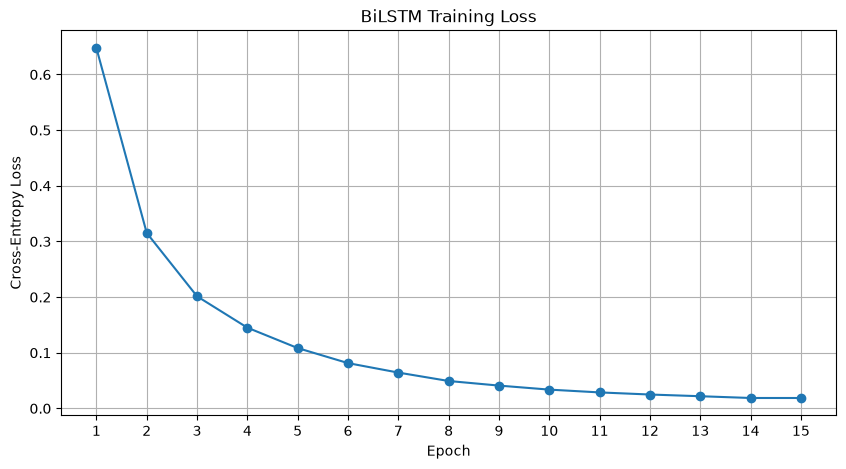

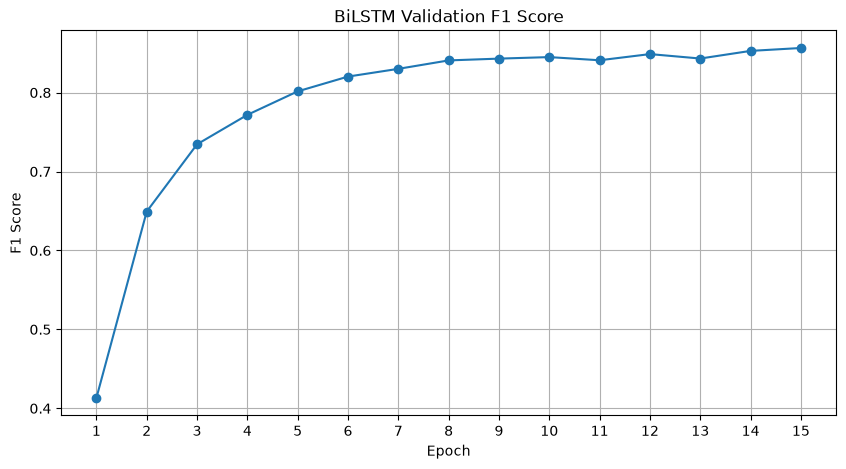

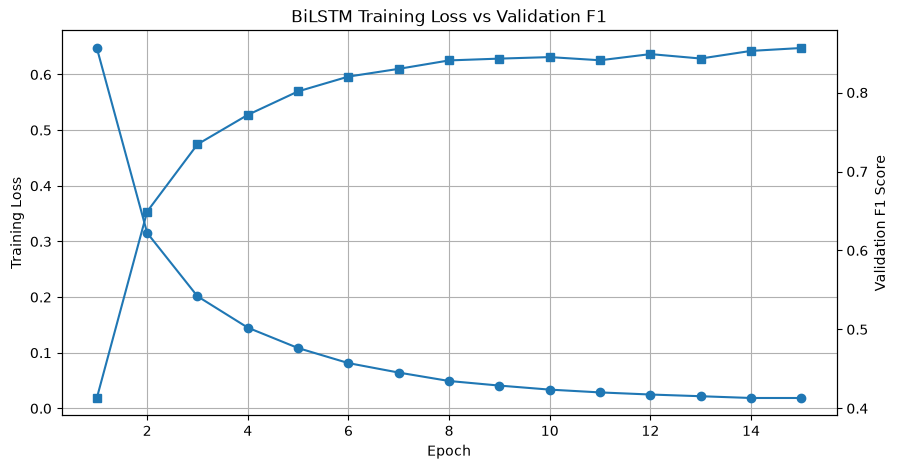

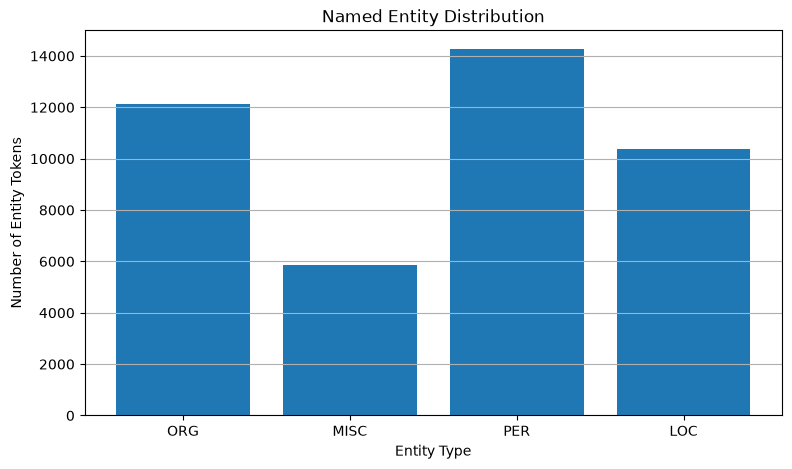

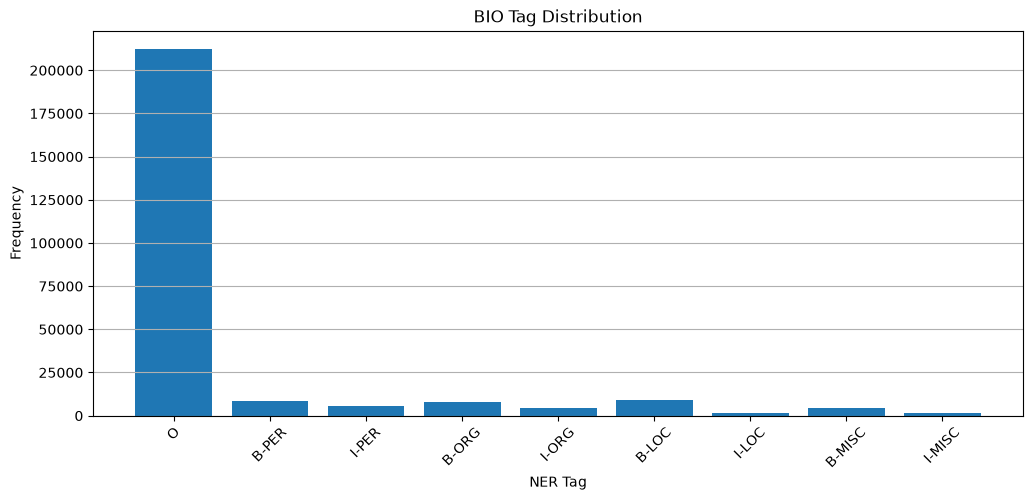

SAMPLE NER PREDICTION
Word                Actual         Predicted      
----------------------------------------------------------------------
+1                  O              O              
Fred                B-PER          B-PER          
Funk                I-PER          I-PER          
through             O              O              
9                   O              O              


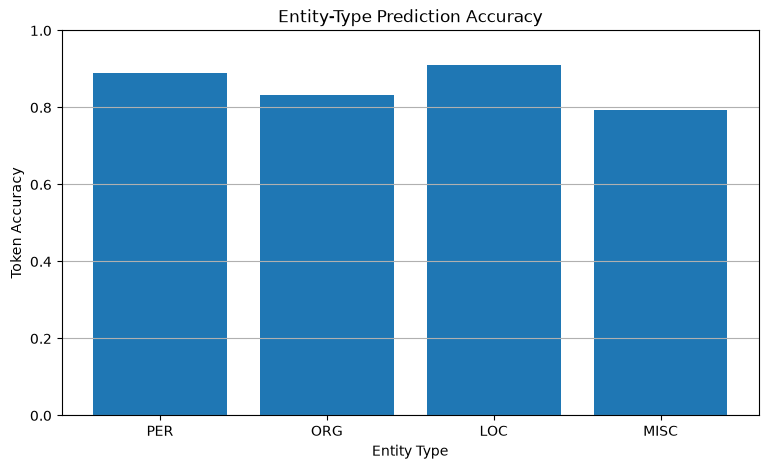


BiLSTM NER VISUALIZATION SUMMARY
Final Validation F1 Score: 0.8565
Vocabulary Size: 10929
Number of BIO Tags: 9

Entity Distribution:
ORG: 12117
MISC: 5861
PER: 14277
LOC: 10391

Entity-Type Accuracy:
PER: 0.8890
ORG: 0.8328
LOC: 0.9110
MISC: 0.7945


In [3]:
# ============================================================
# VISUALIZATIONS
# Named Entity Recognition using BiLSTM
# ============================================================

import matplotlib.pyplot as plt
from collections import Counter


# ------------------------------------------------------------
# 1. Training Loss
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o"
)

plt.title("BiLSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.xticks(range(1, len(train_losses) + 1))
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 2. Validation F1 Score
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(val_f1_scores) + 1),
    val_f1_scores,
    marker="o"
)

plt.title("BiLSTM Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.xticks(range(1, len(val_f1_scores) + 1))
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 3. Training Loss and Validation F1
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    range(1, len(val_f1_scores) + 1),
    val_f1_scores,
    marker="s",
    label="Validation F1"
)

ax2.set_ylabel("Validation F1 Score")

plt.title("BiLSTM Training Loss vs Validation F1")

plt.show()


# ------------------------------------------------------------
# 4. Entity Distribution in the Dataset
# ------------------------------------------------------------

entity_counter = Counter()

for sentence_tags in tags:

    for tag in sentence_tags:

        if tag != "O":

            # Remove B- / I- prefix
            entity_type = tag.split("-")[-1]

            entity_counter[entity_type] += 1


entity_names = list(entity_counter.keys())
entity_counts = list(entity_counter.values())


plt.figure(figsize=(9, 5))

plt.bar(
    entity_names,
    entity_counts
)

plt.title("Named Entity Distribution")
plt.xlabel("Entity Type")
plt.ylabel("Number of Entity Tokens")
plt.grid(
    axis="y"
)

plt.show()


# ------------------------------------------------------------
# 5. BIO Tag Distribution
# ------------------------------------------------------------

tag_counter = Counter()

for sentence_tags in tags:

    for tag in sentence_tags:
        tag_counter[tag] += 1


tag_names = [
    "O",
    "B-PER",
    "I-PER",
    "B-ORG",
    "I-ORG",
    "B-LOC",
    "I-LOC",
    "B-MISC",
    "I-MISC"
]

tag_counts = [
    tag_counter[tag]
    for tag in tag_names
]


plt.figure(figsize=(12, 5))

plt.bar(
    tag_names,
    tag_counts
)

plt.title("BIO Tag Distribution")
plt.xlabel("NER Tag")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(
    axis="y"
)

plt.show()


# ------------------------------------------------------------
# 6. Actual vs Predicted Tags for a Sample Sentence
# ------------------------------------------------------------

sample_index = 0

sample_words = val_sentences[sample_index]

sample_true_tags = true_sequences[sample_index]

sample_pred_tags = pred_sequences[sample_index]


print("=" * 70)
print("SAMPLE NER PREDICTION")
print("=" * 70)

print(
    f"{'Word':<20}"
    f"{'Actual':<15}"
    f"{'Predicted':<15}"
)

print("-" * 70)

for word, actual, predicted in zip(
    sample_words,
    sample_true_tags,
    sample_pred_tags
):

    print(
        f"{word:<20}"
        f"{actual:<15}"
        f"{predicted:<15}"
    )


# ------------------------------------------------------------
# 7. Entity Prediction Accuracy by Type
# ------------------------------------------------------------

entity_types = [
    "PER",
    "ORG",
    "LOC",
    "MISC"
]

entity_correct = {
    entity: 0
    for entity in entity_types
}

entity_total = {
    entity: 0
    for entity in entity_types
}


for true_sentence, pred_sentence in zip(
    true_sequences,
    pred_sequences
):

    for true_tag, pred_tag in zip(
        true_sentence,
        pred_sentence
    ):

        if true_tag != "O":

            entity_type = true_tag.split("-")[-1]

            if entity_type in entity_total:

                entity_total[entity_type] += 1

                if true_tag == pred_tag:

                    entity_correct[entity_type] += 1


entity_accuracy = {}

for entity in entity_types:

    if entity_total[entity] > 0:

        entity_accuracy[entity] = (
            entity_correct[entity]
            /
            entity_total[entity]
        )

    else:

        entity_accuracy[entity] = 0


plt.figure(figsize=(9, 5))

plt.bar(
    entity_accuracy.keys(),
    entity_accuracy.values()
)

plt.title("Entity-Type Prediction Accuracy")
plt.xlabel("Entity Type")
plt.ylabel("Token Accuracy")

plt.ylim(0, 1)

plt.grid(
    axis="y"
)

plt.show()


# ------------------------------------------------------------
# 8. Final Results Summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BiLSTM NER VISUALIZATION SUMMARY")
print("=" * 60)

print(
    f"Final Validation F1 Score: {final_f1:.4f}"
)

print(
    f"Vocabulary Size: {len(word2idx)}"
)

print(
    f"Number of BIO Tags: {len(tag2idx)}"
)

print("\nEntity Distribution:")

for entity, count in entity_counter.items():

    print(
        f"{entity}: {count}"
    )

print("\nEntity-Type Accuracy:")

for entity, accuracy in entity_accuracy.items():

    print(
        f"{entity}: {accuracy:.4f}"
    )

print("=" * 60)

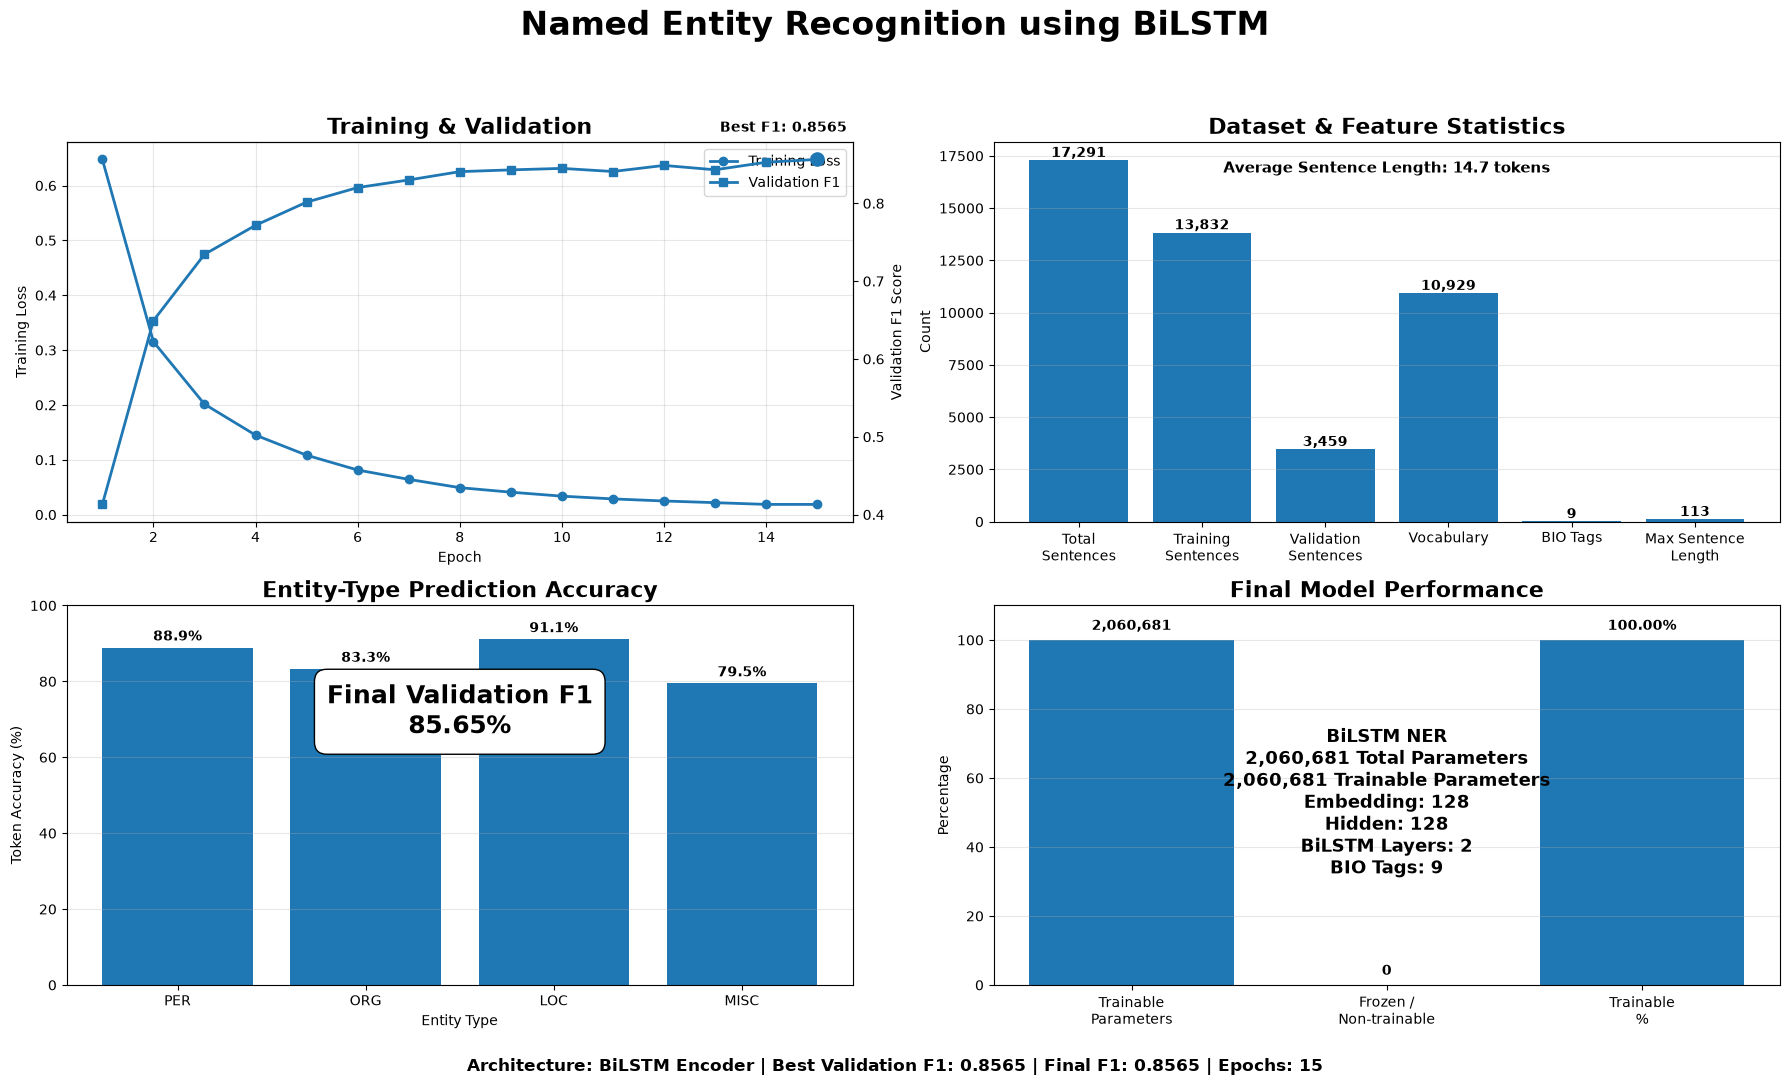

VISUALIZATION SAVED
BiLSTM_NER_Visualization.png


In [4]:
# ============================================================
# FINAL VISUALIZATION DASHBOARD
# Named Entity Recognition using BiLSTM
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# ------------------------------------------------------------
# Parameter statistics
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

non_trainable_params = (
    total_params - trainable_params
)

trainable_percentage = (
    trainable_params / total_params * 100
    if total_params > 0 else 0
)

# ------------------------------------------------------------
# Dataset statistics
# ------------------------------------------------------------

total_sentences = len(sentences)
training_sentences = len(train_sentences)
validation_sentences = len(val_sentences)

vocabulary_size = len(word2idx)
number_of_tags = len(tag2idx)

sentence_lengths = [
    len(sentence)
    for sentence in sentences
]

max_sentence_length = max(
    sentence_lengths
)

average_sentence_length = np.mean(
    sentence_lengths
)

# ------------------------------------------------------------
# Entity statistics
# ------------------------------------------------------------

entity_counter = Counter()

for sentence_tags in tags:

    for tag in sentence_tags:

        if tag != "O":

            entity_type = tag.split("-")[-1]

            entity_counter[
                entity_type
            ] += 1

# Existing entity_accuracy generated
# by the previous visualization/evaluation cell

if "entity_accuracy" not in globals():

    entity_accuracy = {}

    for entity_type in [
        "PER",
        "ORG",
        "LOC",
        "MISC"
    ]:

        entity_accuracy[entity_type] = 0

# ------------------------------------------------------------
# Create dashboard
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 11)
)

fig.suptitle(
    "Named Entity Recognition using BiLSTM",
    fontsize=24,
    fontweight="bold"
)

# ============================================================
# TOP LEFT
# Training & Validation
# ============================================================

ax = axes[0, 0]

epochs_axis = np.arange(
    1,
    len(train_losses) + 1
)

ax.plot(
    epochs_axis,
    train_losses,
    marker="o",
    linewidth=2,
    label="Training Loss"
)

ax2 = ax.twinx()

ax2.plot(
    epochs_axis,
    val_f1_scores,
    marker="s",
    linewidth=2,
    label="Validation F1"
)

ax.set_title(
    "Training & Validation",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax2.set_ylabel("Validation F1 Score")

ax.grid(
    True,
    alpha=0.3
)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)

best_epoch = (
    np.argmax(val_f1_scores) + 1
)

best_f1 = max(
    val_f1_scores
)

ax2.scatter(
    best_epoch,
    best_f1,
    s=90,
    zorder=5
)

ax2.annotate(
    f"Best F1: {best_f1:.4f}",
    (
        best_epoch,
        best_f1
    ),
    xytext=(-70, 20),
    textcoords="offset points",
    fontweight="bold"
)

# ============================================================
# TOP RIGHT
# Dataset & Feature Statistics
# ============================================================

ax = axes[0, 1]

stats_names = [
    "Total\nSentences",
    "Training\nSentences",
    "Validation\nSentences",
    "Vocabulary",
    "BIO Tags",
    "Max Sentence\nLength"
]

stats_values = [
    total_sentences,
    training_sentences,
    validation_sentences,
    vocabulary_size,
    number_of_tags,
    max_sentence_length
]

bars = ax.bar(
    stats_names,
    stats_values
)

ax.set_title(
    "Dataset & Feature Statistics",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Count")

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    stats_values
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.text(
    0.5,
    0.92,
    f"Average Sentence Length: "
    f"{average_sentence_length:.1f} tokens",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    fontweight="bold"
)

# ============================================================
# BOTTOM LEFT
# Entity-Type Evaluation
# ============================================================

ax = axes[1, 0]

entity_names = list(
    entity_accuracy.keys()
)

entity_values = [
    entity_accuracy[name] * 100
    for name in entity_names
]

bars = ax.bar(
    entity_names,
    entity_values
)

ax.set_title(
    "Entity-Type Prediction Accuracy",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Entity Type")
ax.set_ylabel("Token Accuracy (%)")

ax.set_ylim(
    0,
    100
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    entity_values
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.text(
    0.5,
    0.72,
    f"Final Validation F1\n"
    f"{final_f1 * 100:.2f}%",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="black"
    )
)

# ============================================================
# BOTTOM RIGHT
# Final Model Performance
# ============================================================

ax = axes[1, 1]

performance_names = [
    "Trainable\nParameters",
    "Frozen /\nNon-trainable",
    "Trainable\n%"
]

performance_values = [
    100,
    0,
    trainable_percentage
]

bars = ax.bar(
    performance_names,
    performance_values
)

ax.set_ylim(
    0,
    110
)

ax.set_ylabel("Percentage")

ax.set_title(
    "Final Model Performance",
    fontsize=16,
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for i, bar in enumerate(bars):

    if i == 0:
        label = f"{trainable_params:,}"
    elif i == 1:
        label = f"{non_trainable_params:,}"
    else:
        label = f"{trainable_percentage:.2f}%"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        label,
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.text(
    0.5,
    0.48,
    "BiLSTM NER\n"
    f"{total_params:,} Total Parameters\n"
    f"{trainable_params:,} Trainable Parameters\n"
    f"Embedding: 128\n"
    f"Hidden: 128\n"
    f"BiLSTM Layers: 2\n"
    f"BIO Tags: {number_of_tags}",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# FOOTER
# ============================================================

fig.text(
    0.5,
    0.015,
    f"Architecture: BiLSTM Encoder | "
    f"Best Validation F1: {best_f1:.4f} | "
    f"Final F1: {final_f1:.4f} | "
    f"Epochs: {len(train_losses)}",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0.04, 1, 0.94]
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

output_file = "BiLSTM_NER_Visualization.png"

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("VISUALIZATION SAVED")
print("=" * 70)
print(output_file)